In [1]:
from scipy import stats
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

from StatTools.analysis.dfa import dfa
from StatTools.filters.kalman_filter import KalmanFilter
from StatTools.generators.kasdin_generator import ERKasdinGenerator
from StatTools.generators.kasdin_generator import create_kasdin_generator
from StatTools.experimental.filters.symbolic_kalman import (
    get_sympy_filter_matrix,
    refine_filter_matrix,
)

## 1. Real data analysis

In [ ]:
DATA_DIR = "research/kalman_filter/reconstruction_of_long-term_complex_system_dynamics/data"
H_O = 1
df_rwi = pd.read_csv(os.path.join(DATA_DIR, "tree_rwi.csv"), index_col="year")

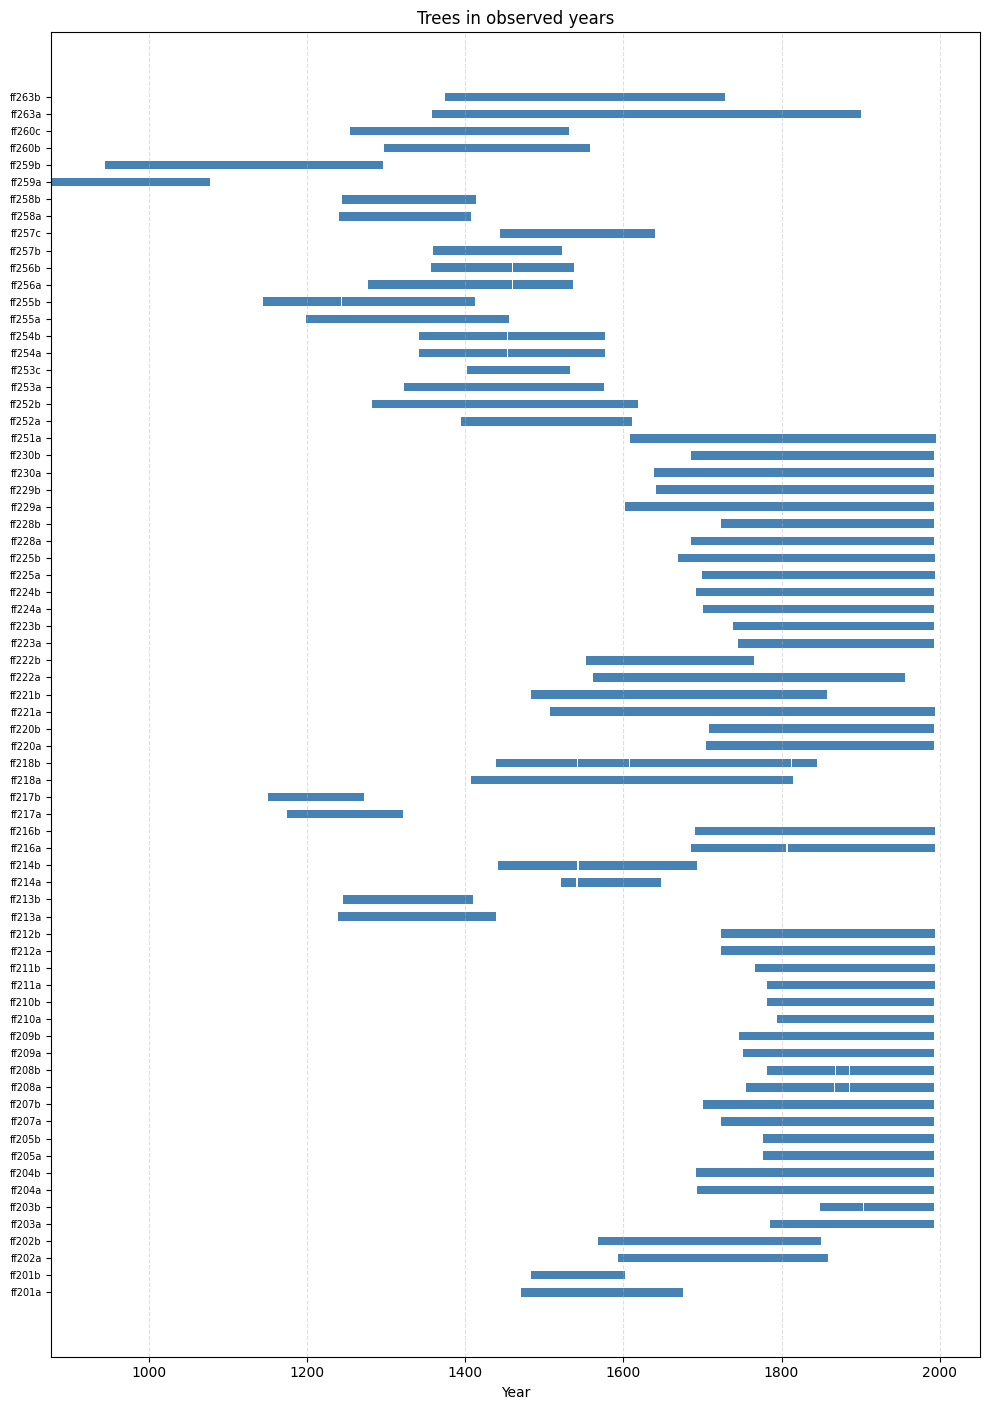

In [3]:
trees = df_rwi.columns.tolist()
n_trees = len(trees)

fig, ax = plt.subplots(figsize=(10, max(6, n_trees * 0.2)))

for i, tree in enumerate(trees):
    valid_years = df_rwi.index[df_rwi[tree].notna()].tolist()
    if not valid_years:
        continue
    segments = []
    start = valid_years[0]
    prev = valid_years[0]
    for y in valid_years[1:]:
        if y - prev > 1:
            segments.append((start, prev))
            start = y
        prev = y
    segments.append((start, prev))
    for seg_start, seg_end in segments:
        ax.barh(
            i, seg_end - seg_start + 1, left=seg_start, height=0.5, color="steelblue"
        )

ax.set_yticks(range(n_trees))
ax.set_yticklabels(trees, fontsize=7)
ax.set_xlabel("Year")
ax.set_title("Trees in observed years")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [4]:
all_years = np.arange(df_rwi.index.min(), df_rwi.index.max() + 1)
df_full = df_rwi.reindex(all_years)  # no data → NaN

data = df_full.to_numpy()  # shape: (n_years, n_trees)
years = df_full.index.to_numpy()
n_years = len(years)
total_years = years[-1] - years[0] + 1

print(f"trees: {data.shape[1]}, years: {data.shape[0]} ({years[0]}–{years[-1]})")
print(f"dtype: {data.dtype}, NaN: {np.isnan(data).sum()}")

trees: 71, years: 1118 (877–1994)
dtype: float64, NaN: 60636


Median: 16 trees per year
Min / Max: 1 / 42
Median lenght: 258 years
Min / Max lenght: 119 / 543 years


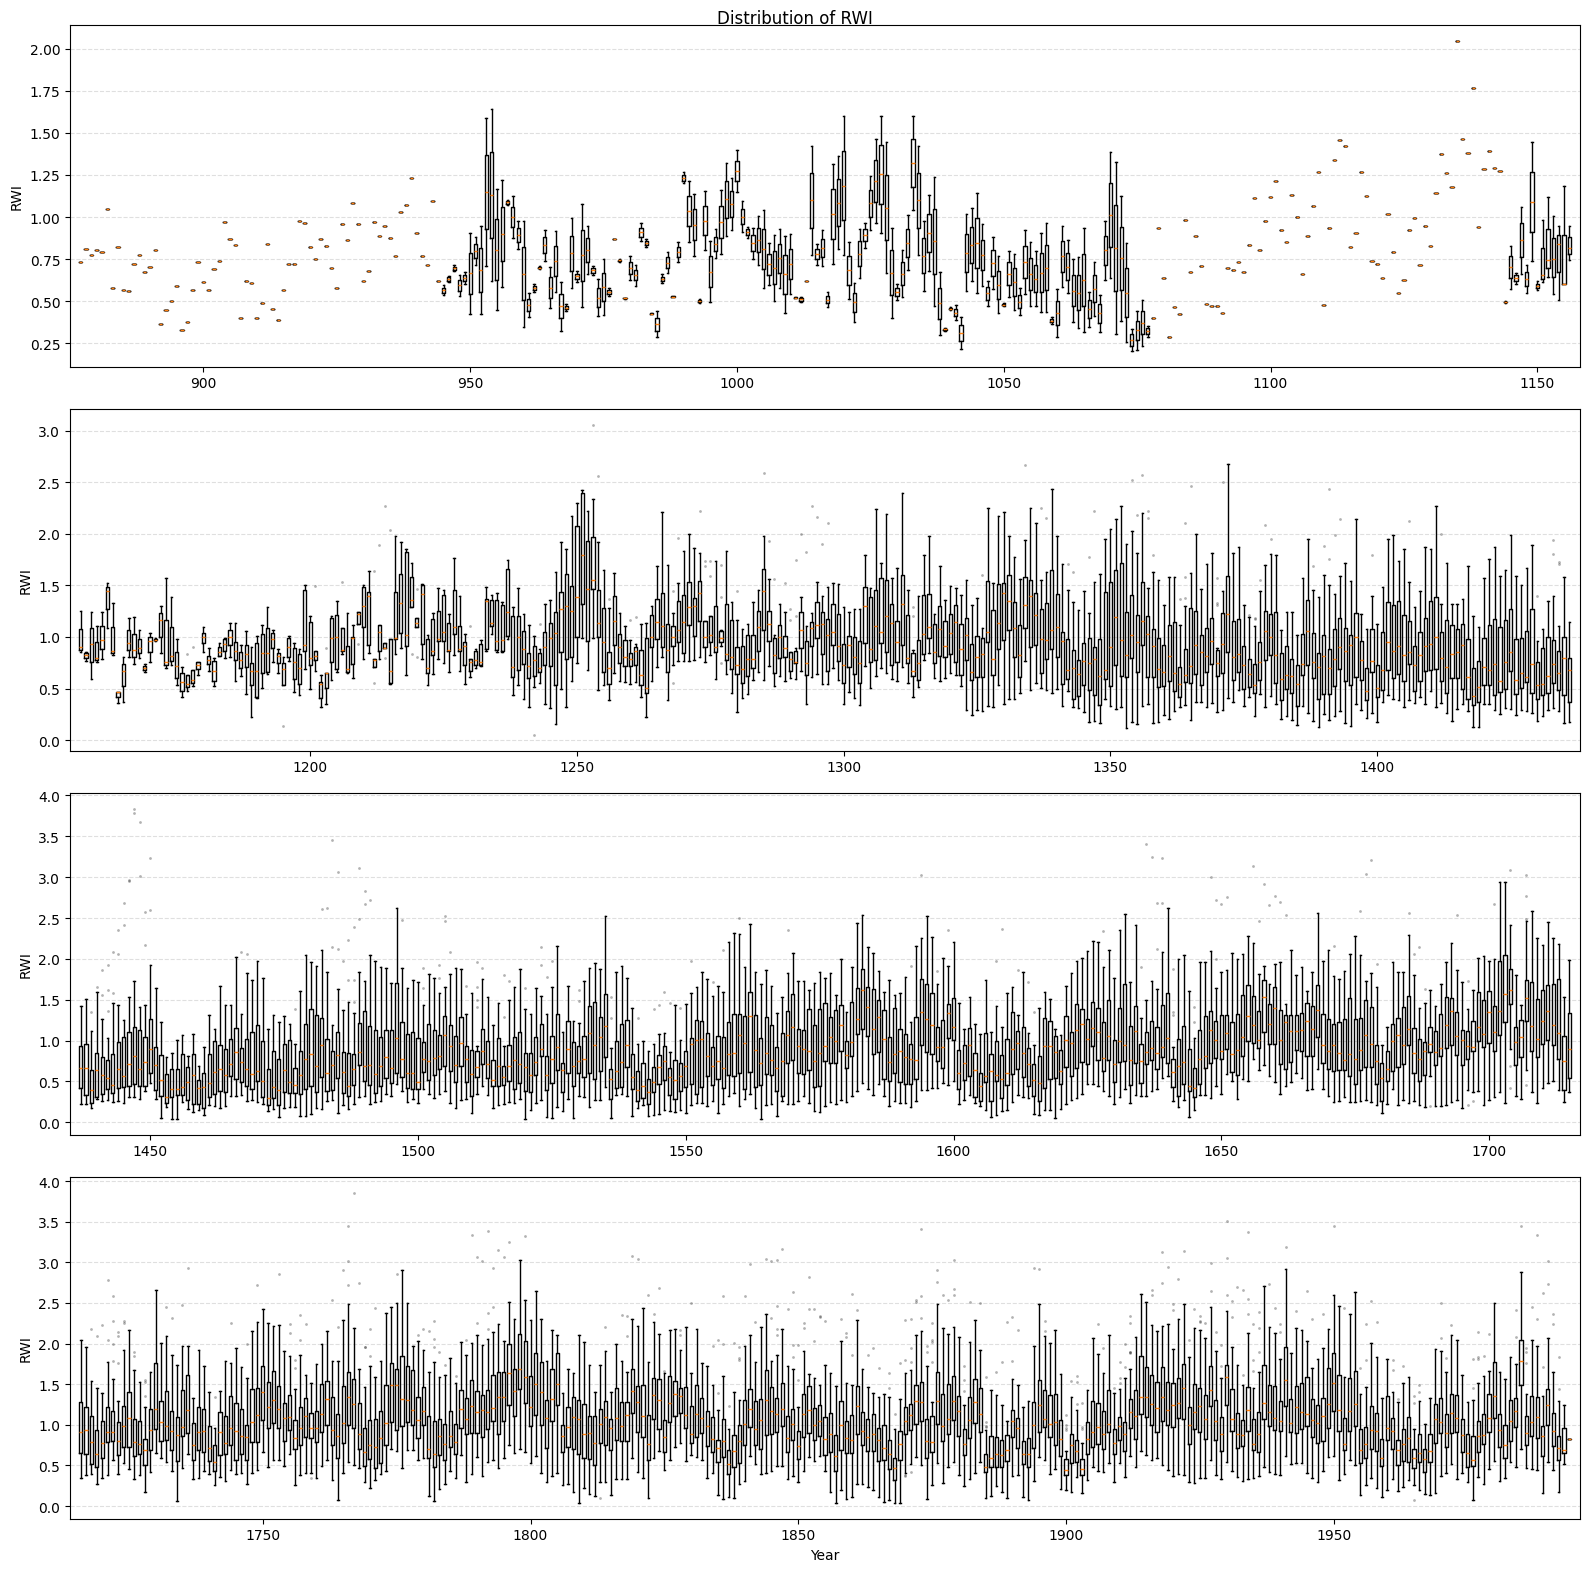

In [5]:
valid_mask = ~np.all(np.isnan(data), axis=1)
valid_idx = np.where(valid_mask)[0]
box_data = [data[i][~np.isnan(data[i])] for i in valid_idx]
valid_years_bp = years[valid_idx]

n_rows = 4
chunks = np.array_split(np.arange(len(valid_idx)), n_rows)

trees_per_year = np.array([len(box_data[j]) for j in range(len(valid_idx))])
median_sample = int(np.median(trees_per_year))
print(f"Median: {median_sample} trees per year")
print(f"Min / Max: {trees_per_year.min()} / {trees_per_year.max()}")
series_lengths = np.sum(~np.isnan(data), axis=0)
print(f"Median lenght: {int(np.median(series_lengths))} years")
print(f"Min / Max lenght: {series_lengths.min()} / {series_lengths.max()} years")

fig, axes = plt.subplots(n_rows, 1, figsize=(16, 4 * n_rows))
for ax, chunk in zip(axes, chunks):
    ax.boxplot(
        [box_data[j] for j in chunk],
        positions=valid_years_bp[chunk],
        widths=0.6,
        manage_ticks=False,
        flierprops=dict(marker=".", markersize=2, alpha=0.3),
    )
    ax.set_xlim(valid_years_bp[chunk[0]] - 2, valid_years_bp[chunk[-1]] + 2)
    ax.set_ylabel("RWI")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

axes[-1].set_xlabel("Year")
fig.suptitle("Distribution of RWI")
plt.tight_layout()
plt.show()

## 2. Applying the Kalman filter

In [6]:
def normalize(data: np.ndarray[np.float64]) -> np.ndarray[np.float64]:
    mean = np.nanmean(data)
    std = np.nanstd(data)
    return (data - mean) / std if std != 0 else (data - mean)


def get_F_matrix(order: int, H_O: np.array, length: int) -> np.array:
    generator = create_kasdin_generator(H_O, length=length)
    ar_filter = generator.get_filter_coefficients()
    number_matrix = refine_filter_matrix(
        get_sympy_filter_matrix(order), order, ar_filter
    )
    number_matrix = np.array(number_matrix, dtype=np.float64)
    return number_matrix


def get_Q_matrix(order: int, H_O: np.array, length: int) -> np.array:
    model_generator = ERKasdinGenerator(H_O, length=length)
    model_signal = model_generator.get_full_sequence()
    signal = normalize(model_signal)
    ridge = 1e-6 * np.var(signal)
    Q = np.eye(order) * ridge
    Q[0, 0] = np.var(signal)
    return Q


def get_H_matrix(order: int) -> np.array:
    H = np.zeros(order)
    H[0] = 1
    return H


def get_R_matrix(points):
    return np.array([[np.nanvar(points)]])


def init_kf(H_O, noise, method, order, length):
    if method == "Kasdin":
        F = get_F_matrix(order, H_O, length)
    H = get_H_matrix(order)
    if isinstance(noise, (np.ndarray, list)):
        R = get_R_matrix(noise)
    else:
        R = np.array([[noise]])
    Q = get_Q_matrix(order, H_O, length)

    kf = KalmanFilter(order, 1, F=F, H=H, R=R, Q=Q)
    return kf

### Data augmentation

In [7]:
df_augmented = df_full.copy().drop(
    [
        "ff201a",
        "ff201b",
        "ff202a",
        "ff202b",
        "ff203a",
        "ff203b",
        "ff204a",
        "ff204b",
        "ff205a",
        "ff205b",
        "ff207a",
        "ff207b",
        "ff208a",
        "ff208b",
        "ff209a",
        "ff209b",
        "ff210a",
        "ff210b",
        "ff211a",
        "ff211b",
        "ff213a",
        "ff213b",
        "ff216a",
        "ff216b",
        "ff217a",
        "ff217b",
        "ff218a",
        "ff218b",
        "ff220a",
        "ff220b",
        "ff221a",
        "ff221b",
        "ff222a",
        "ff222b",
        "ff224a",
        "ff224b",
        "ff225a",
        "ff225b",
        "ff228a",
        "ff228b",
        "ff229a",
        "ff229b",
        "ff252a",
        "ff252b",
        "ff253a",
        "ff253c",
        "ff254a",
        "ff254b",
        "ff255a",
        "ff255b",
        "ff256a",
        "ff256b",
        "ff257b",
        "ff257c",
        "ff260b",
        "ff260c",
    ],
    axis=1,
)
data_aug = df_augmented.to_numpy()
mean_signal_aug = np.zeros(n_years)
for i, year in enumerate(data_aug):
    mean_signal_aug[i] = np.nanmean(year)

In [8]:
print(
    f"trees: {data_aug.shape[1]}, years: {data_aug.shape[0]} ({years[0]}–{years[-1]})"
)
print(f"dtype: {data_aug.dtype}, NaN: {np.isnan(data_aug).sum()}")

trees: 15, years: 1118 (877–1994)
dtype: float64, NaN: 12520


In [9]:
all_years = df_full.index
total_by_year = df_full.notna().sum(axis=1)
aug_by_year = df_augmented.notna().sum(axis=1).reindex(all_years, fill_value=0)
pct_by_year = (aug_by_year / total_by_year.replace(0, pd.NA) * 100).fillna(0)

trees_stats = pd.DataFrame(
    {
        "total": total_by_year,
        "remaining": aug_by_year,
        "pct": pct_by_year.round(1),
    }
)

min_pct = trees_stats["pct"].min()
min_year = trees_stats["pct"].idxmin()
print(f"\nMin: {min_pct:.1f}%")
print(f"Median: {np.median(trees_stats['pct']):.1f}%")


Min: 12.5%
Median: 22.9%


### Filtering

In [10]:
order = 8
method = "Kasdin"

mean_signal = np.zeros(total_years)
for i, year in enumerate(data):
    mean_signal[i] = np.nanmean(year)
recovered_signal = np.zeros(total_years)
kf = init_kf(H_O, 0, method, order, total_years)

for i, year in enumerate(data):
    valid = year[~np.isnan(year)]
    if valid.size != 0:
        year_mean = np.nanmean(valid)
        R = get_R_matrix(valid)
        kf._R = R
    else:
        year_mean = None
    kf.predict()
    kf.adjust(np.array([[year_mean]]))
    recovered_signal[i] = kf.get_current_measurement().item()


recovered_signal_aug = np.zeros(total_years)
kf = init_kf(H_O, 0, method, order, total_years)

for i, year in enumerate(data_aug):
    valid = year[~np.isnan(year)]
    if valid.size != 0:
        year_mean = np.nanmean(valid)
        R = get_R_matrix(valid)
        kf._R = R
    else:
        year_mean = None
    kf.predict()
    kf.adjust(np.array([[year_mean]]))
    recovered_signal_aug[i] = kf.get_current_measurement().item()

## 3. Checking the Hurst exponent

In [11]:
# Load dplR data
df_rwi_dplr = pd.read_csv(
    os.path.join(DATA_DIR, "tree_rwi_dplr_71.csv"), index_col="year"
)
df_rwi_dplr_aug = pd.read_csv(
    os.path.join(DATA_DIR, "tree_rwi_dplr_15.csv"), index_col="year"
)

trees = df_rwi_dplr.columns.tolist()
n_trees = len(trees)

all_years = np.arange(df_rwi_dplr.index.min(), df_rwi_dplr.index.max() + 1)
df_full_drpl = df_rwi_dplr.reindex(all_years)

data_dplr = df_full_drpl.to_numpy()
years = df_full_drpl.index.to_numpy()
n_years = len(years)
total_years = years[-1] - years[0] + 1

mean_signal_dplr = np.zeros(total_years)
for i, year in enumerate(data_dplr):
    mean_signal_dplr[i] = np.nanmean(year)

print(
    f"trees: {data_dplr.shape[1]}, years: {data_dplr.shape[0]} ({years[0]}–{years[-1]})"
)
print(f"dtype: {data_dplr.dtype}, NaN: {np.isnan(data_dplr).sum()}")


trees = df_rwi_dplr_aug.columns.tolist()
n_trees = len(trees)

all_years = np.arange(df_rwi_dplr_aug.index.min(), df_rwi_dplr_aug.index.max() + 1)
df_full_drpl_aug = df_rwi_dplr_aug.reindex(all_years)

data_dplr_aug = df_full_drpl_aug.to_numpy()
years = df_full_drpl_aug.index.to_numpy()
n_years = len(years)
total_years = years[-1] - years[0] + 1

mean_signal_dplr_aug = np.zeros(total_years)
for i, year in enumerate(data_dplr_aug):
    mean_signal_dplr_aug[i] = np.nanmean(year)

print(
    f"trees: {data_dplr_aug.shape[1]}, years: {data_dplr_aug.shape[0]} ({years[0]}–{years[-1]})"
)
print(f"dtype: {data_dplr_aug.dtype}, NaN: {np.isnan(data_dplr_aug).sum()}")

trees: 71, years: 1118 (877–1994)
dtype: float64, NaN: 60636
trees: 15, years: 1118 (877–1994)
dtype: float64, NaN: 12520


In [12]:
def _compute_h(sig):
    sig = np.array(sig)
    s_vals, f2_vals = dfa(sig, degree=2, processes=1)
    log_s = np.log(s_vals)
    log_f = np.log(np.sqrt(f2_vals))
    return round(stats.linregress(log_s, log_f).slope, 3)

In [13]:
print(
    f"Method\t\tH₀\tĤ₀\tHᵣ\tĤᵣ\n\
{method}, {order}\t{_compute_h(mean_signal):.2f}\t{_compute_h(mean_signal_aug):.2f}\t{_compute_h(recovered_signal):.2f}\t{_compute_h(recovered_signal_aug):.2f}\
\ndplr\t\t{_compute_h(mean_signal):.2f}\t{_compute_h(mean_signal_aug):.2f}\t{_compute_h(mean_signal_dplr):.2f}\t{_compute_h(mean_signal_dplr_aug):.2f}"
)

Method		H₀	Ĥ₀	Hᵣ	Ĥᵣ
Kasdin, 8	0.91	0.94	0.94	0.96
dplr		0.91	0.94	0.85	0.90


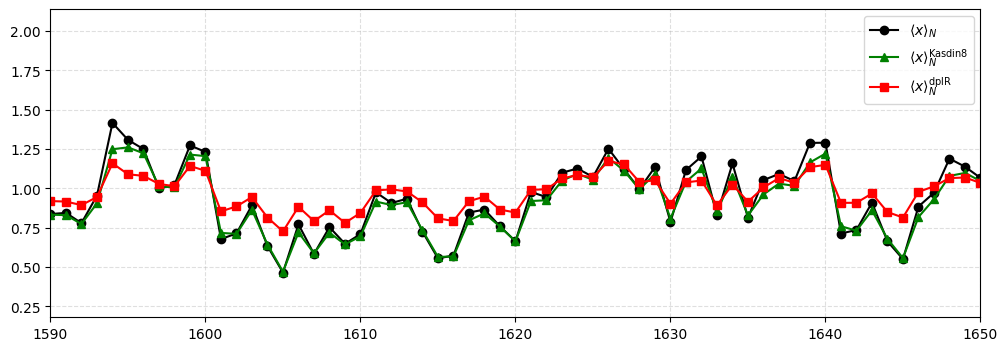

In [14]:
plt.figure(figsize=(12, 4))
plt.plot(years, mean_signal, "-o", label=f"$\\langle x \\rangle_N$", color="k")
plt.plot(
    years,
    recovered_signal,
    "-^",
    color="green",
    label=f"$\\langle x \\rangle_N^\\text{{{method}{order}}}$",
)
plt.plot(
    years,
    mean_signal_dplr,
    "-s",
    color="r",
    label=f"$\\langle x \\rangle_N^\\text{{dplR}}$",
)
plt.grid(linestyle="--", alpha=0.4)
plt.legend()
plt.xlim(1590, 1650)
plt.savefig("research/data/output/recovered.png")
plt.savefig("research/data/output/recovered.svg")
plt.show()

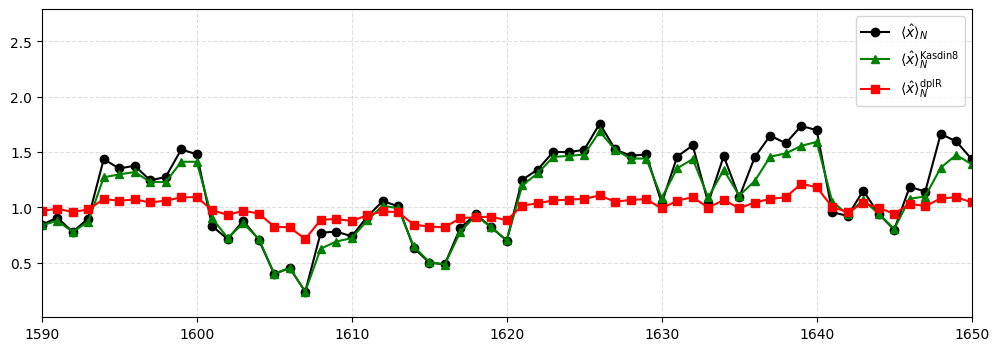

In [15]:
plt.figure(figsize=(12, 4))
plt.plot(
    years, mean_signal_aug, "-o", label=f"$\\langle \\hat{{x}} \\rangle_N$", color="k"
)
plt.plot(
    years,
    recovered_signal_aug,
    "-^",
    color="green",
    label=f"$\\langle \\hat{{x}} \\rangle_N^\\text{{{method}{order}}}$",
)
plt.plot(
    years,
    mean_signal_dplr_aug,
    "-s",
    color="r",
    label=f"$\\langle \\hat{{x}} \\rangle_N^\\text{{dplR}}$",
)
plt.grid(linestyle="--", alpha=0.4)
plt.legend()
plt.xlim(1590, 1650)
plt.savefig("research/data/output/recovered_distorted.png")
plt.savefig("research/data/output/recovered_distorted.svg")
plt.show()

## Checking the ACF

In [16]:
N_LAGS = 300

In [17]:
def integrated_acf_error(acf_true, acf_estimated, max_lag=None):
    if max_lag is None:
        max_lag = min(len(acf_true), len(acf_estimated))
    err = np.mean(np.abs(acf_true[:max_lag] - acf_estimated[:max_lag]))
    return err


def get_rq(signal):
    signal = signal - np.median(signal)
    crossings = []
    for i in range(1, len(signal)):
        if signal[i - 1] < 0 and signal[i] >= 0:
            crossings.append(i)
    r = np.diff(np.array(crossings)).astype(float)
    return np.mean(r)

In [18]:
acf_mean = acf(mean_signal, nlags=N_LAGS)
acf_kalman = acf(recovered_signal, nlags=N_LAGS)
acf_dplr = acf(mean_signal_dplr, nlags=N_LAGS)

In [19]:
err_kalman = integrated_acf_error(acf_mean, acf_kalman, max_lag=N_LAGS)
err_dplr = integrated_acf_error(acf_mean, acf_dplr, max_lag=N_LAGS)
print(f"err_kalman: {err_kalman:.4f}")
print(f"err_dplr: {err_dplr:.4f}")

err_kalman: 0.0092
err_dplr: 0.1094


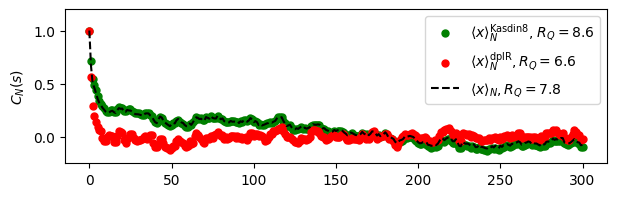

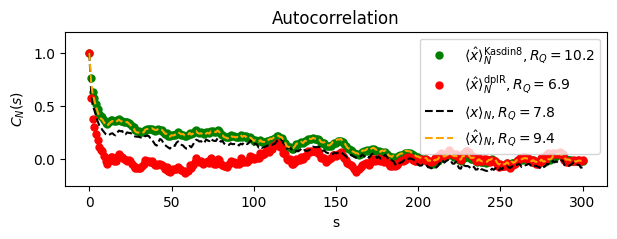

In [20]:
fig, ax = plt.subplots(figsize=(7, 2))
plot_acf(
    recovered_signal,
    lags=N_LAGS,
    ax=ax,
    marker="o",
    alpha=None,
    color="green",
    label=f"$\\langle x \\rangle_N^\\text{{{method}{order}}}$, $R_Q=${get_rq(recovered_signal):.1f}",
    use_vlines=False,
    title=None,
)
plot_acf(
    mean_signal_dplr,
    lags=N_LAGS,
    ax=ax,
    marker="o",
    color="r",
    alpha=None,
    label=f"$\\langle x \\rangle_N^\\text{{dplR}}, R_Q=${get_rq(mean_signal_dplr):.1f}",
    use_vlines=False,
    title=None,
)
plot_acf(
    mean_signal,
    lags=N_LAGS,
    ax=ax,
    color="k",
    alpha=None,
    marker="",
    linestyle="--",
    label=f"$\\langle x \\rangle_N, R_Q=${get_rq(mean_signal):.1f}",
    use_vlines=False,
    title=None,
)

plt.ylabel("$C_N(s)$")
plt.ylim(-0.25, 1.2)
plt.legend()
# plt.title("Autocorrelation Functions")
plt.savefig("research/data/output/acf_trees.png")
plt.savefig("research/data/output/acf_trees.svg")
plt.show()


fig, ax = plt.subplots(figsize=(7, 2))
plot_acf(
    recovered_signal_aug,
    lags=N_LAGS,
    ax=ax,
    marker="o",
    color="green",
    alpha=None,
    label=f"$\\langle \\hat{{x}} \\rangle_N^\\text{{{method}{order}}}, R_Q=${get_rq(recovered_signal_aug):.1f}",
    use_vlines=False,
    title=None,
)
plot_acf(
    mean_signal_dplr_aug,
    lags=N_LAGS,
    ax=ax,
    marker="o",
    color="r",
    alpha=None,
    label=f"$\\langle \\hat{{x}} \\rangle_N^\\text{{dplR}}, R_Q=${get_rq(mean_signal_dplr_aug):.1f}",
    use_vlines=False,
    title=None,
)
plot_acf(
    mean_signal,
    color="k",
    marker="",
    linestyle="--",
    alpha=None,
    lags=N_LAGS,
    ax=ax,
    label=f"$\\langle x \\rangle_N, R_Q=${get_rq(mean_signal):.1f}",
    use_vlines=False,
    title=None,
)
plot_acf(
    mean_signal_aug,
    lags=N_LAGS,
    ax=ax,
    marker="",
    color="orange",
    linestyle="--",
    alpha=None,
    label=f"$\\langle \\hat{{x}} \\rangle_N, R_Q=${get_rq(mean_signal_aug):.1f}",
    use_vlines=False,
)
plt.xlabel("s")
plt.ylabel("$C_N(s)$")
plt.ylim(-0.25, 1.2)
plt.legend()
plt.savefig("research/data/output/acf_trees_distorted.png")
plt.savefig("research/data/output/acf_trees_distorted.svg")
plt.show()